In [6]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [7]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import os
from os.path import abspath, dirname

In [8]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [9]:
#dycore = 'CAM-SE'
#res = 'se_ne60'
#test_name_start = 'cam_6_4_100'
#lev_no = 'ztop20km_L57'
#extra_name = 'tau_1_10'

dycore = 'CAM-FV3'
res = 'fv3_C192'
test_name_start = 'cam_6_4_070_horiz_mount_flow'
lev_no = 'ztop20km_L57'
extra_name = 'tau_1_10_no_vortdamp'

case = f'{test_name_start}_{res}_{lev_no}'

if dycore == 'CAM-FV3':
    nc_rot = f'{case}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name}.regrid.0.5x0.5.nc'
    nc_omega0 = f'{case}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name}.regrid.0.5x0.5.nc'
else:
    nc_rot = f'{case}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name}.nc'
    nc_omega0 = f'{case}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name}.nc'


In [10]:
run_base = "/glade/derecho/scratch/timand/"

run_path_omega0 = run_base + case + '/run/' + nc_omega0
run_path_rot = run_base + case + '/run/' + nc_rot

nc_omega0 = Dataset(run_path_omega0)
nc_rot = Dataset(run_path_rot)

print(run_path_omega0)
print(run_path_rot)

/glade/derecho/scratch/timand/cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57/run/cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57.cam.h0i.0001-01-01-00000_vortex_omega0_tau_1_10_no_vortdamp.regrid.0.5x0.5.nc
/glade/derecho/scratch/timand/cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57/run/cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57.cam.h0i.0001-01-01-00000_vortex_with_rot_tau_1_10_no_vortdamp.regrid.0.5x0.5.nc


In [11]:
time = nc_omega0['time'][:]
lat = nc_omega0['lat'][:] 
lon = nc_omega0['lon'][:] 

In [12]:
lat_crop_up = 50.
lat_cent_down = -10.
lat_ticks = np.linspace(0., 40., 3)

lon_crop_left = 160.
lon_crop_right = 300.
lon_ticks = np.linspace(180., 300., 4)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

print(lat_inds)
print(lon_inds)

[160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249
 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267
 268 269 270 271 272 273 274 275 276 277 278 279 280]
[320 321 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337
 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352 353 354 355
 356 357 358 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373
 374 375 376 377 378 379 380 381 382 383 384 385 386 387 388 389 390 391
 392 393 394 395 396 397 398 399 400 401 402 403 404 405 406 407 408 409
 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426 427
 428 429 430 431 432 433 434 435 436 437 438 439 440 441 442 443 444 4

In [13]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

lat_crop_up = 50.
lat_cent_down = -10.
lat_ticks = np.linspace(0., 40., 3)

lon_crop_left = 160.
lon_crop_right = 300.
lon_ticks = np.linspace(180., 300., 4)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

In [14]:
# Time indices
t_idxs = np.array([20,40,60])

t1 = time[t_idxs[0]]
t2 = time[t_idxs[1]]
t3 = time[t_idxs[2]]

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [15]:
# Interpolations of U and T

u1_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u2_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u3_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

v1_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['V'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v2_omega0 = z_interp(nc_omega0['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_omega0['V'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v3_omega0 = z_interp(nc_omega0['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_omega0['V'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

#T1_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
#T2_omega0 = z_interp(nc_omega0['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
#T3_omega0 = z_interp(nc_omega0['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

u1_rot = z_interp(nc_rot['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u2_rot = z_interp(nc_rot['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u3_rot = z_interp(nc_rot['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

v1_rot = z_interp(nc_rot['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_rot['V'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v2_rot = z_interp(nc_rot['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_rot['V'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v3_rot = z_interp(nc_rot['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_rot['V'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

#T1_rot = z_interp(nc1_rot['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc1_rot['T'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
#T2_rot = z_interp(nc2_rot['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc2_rot['T'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
#T3_rot = z_interp(nc3_rot['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc3_rot['T'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [16]:
def compute_rel_vorticity(U, V, lat_crop, lon_crop, time):
    uv_ds = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], U), V=(['lat', 'lon'], V)), coords = dict(time=time, lat=lat_crop, lon=lon_crop))
    uv_ds['U'].attrs["units"] = "m/s"
    uv_ds['V'].attrs["units"] = "m/s"
    return mpcalc.vorticity(uv_ds['U'], uv_ds['V'])

In [17]:
vort1_omega0 = compute_rel_vorticity(u1_omega0, v1_omega0, lat_crop, lon_crop, t1)
vort2_omega0 = compute_rel_vorticity(u2_omega0, v2_omega0, lat_crop, lon_crop, t2)
vort3_omega0 = compute_rel_vorticity(u3_omega0, v3_omega0, lat_crop, lon_crop, t3)

vort1_rot = compute_rel_vorticity(u1_rot, v1_rot, lat_crop, lon_crop, t1)
vort2_rot = compute_rel_vorticity(u2_rot, v2_rot, lat_crop, lon_crop, t2)
vort3_rot = compute_rel_vorticity(u3_rot, v3_rot, lat_crop, lon_crop, t3)

In [18]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1_omega0  = (u1_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2_omega0  = (u2_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3_omega0  = (u3_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals1_rot  = (u1_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2_rot  = (u2_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3_rot  = (u3_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
#T1_omega0 = T1_omega0 - T0
#T2_omega0 = T2_omega0 - T0
#T3_omega0 = T3_omega0 - T0
#T1_rot = T1_rot - T0
#T2_rot = T2_rot - T0
#T3_rot = T3_rot - T0

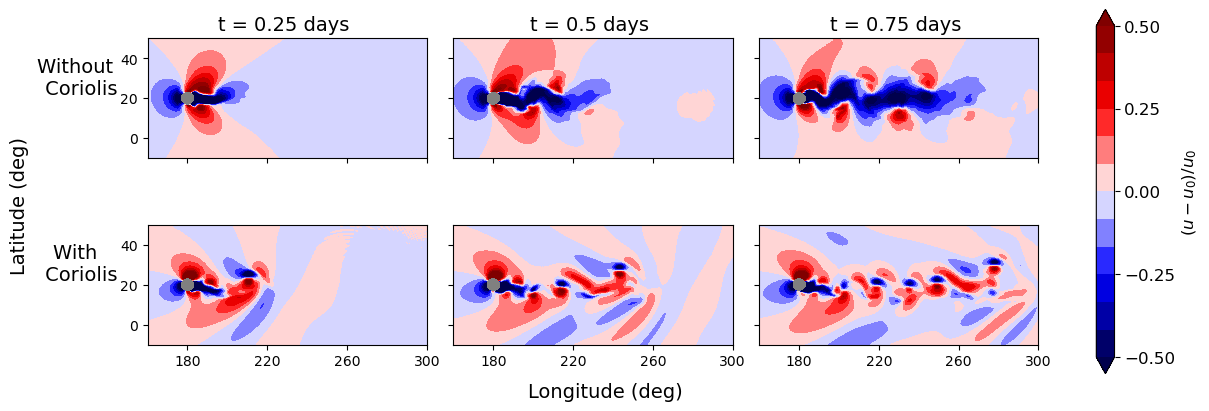

In [28]:
# U over time, both omega0 and with rot
U_cmap = copy.copy(matplotlib.cm.seismic)
#U_cmap = matplotlib.cm.RdYlBu_r
#U_cmap.set_under('k')
#U_cmap.set_over('white')

fig, axes = plt.subplots(2,3, sharey=True, sharex=True, figsize = (12,4), layout="constrained")
(ax1, ax2, ax3), (ax4,ax5,ax6) = axes

#U_conts = np.linspace(-1, 1, 17)
#tick_range = np.linspace(-1, 1, 5)
#norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

U_conts = np.linspace(-0.5, 0.5, 13)
tick_range = np.linspace(-0.5, 0.5, 5)
norm = colors.TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.5)

plot1 = ax1.contourf(LON, LAT, U_field_vals1_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, U_field_vals3_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, U_field_vals1_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot5 = ax5.contourf(LON, LAT, U_field_vals2_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot6 = ax6.contourf(LON, LAT, U_field_vals3_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
#ax1.contour(LON, LAT, U_field_vals1_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
#ax2.contour(LON, LAT, U_field_vals2_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
#ax3.contour(LON, LAT, U_field_vals3_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
#ax4.contour(LON, LAT, U_field_vals1_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
#ax5.contour(LON, LAT, U_field_vals2_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
#ax6.contour(LON, LAT, U_field_vals3_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')


ax1.set_ylabel('Without \n Coriolis', rotation=0, labelpad=30, size=14)
ax4.set_ylabel('With \n Coriolis', rotation=0, labelpad=30, size=14)

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')
ax5.set_aspect('equal')
ax6.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")
ax5.set_facecolor("grey")
ax6.set_facecolor("grey")

cb = plt.colorbar(plot6, ax=axes, ticks = tick_range, fraction=0.1)
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f't = {time[t_idxs[0]]} days ', size=label_size)
ax2.set_title(f't = {time[t_idxs[1]]} days ', size=label_size)
ax3.set_title(f't = {time[t_idxs[2]]} days ', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
plt.savefig('figures/vortex_U_over_time.png')

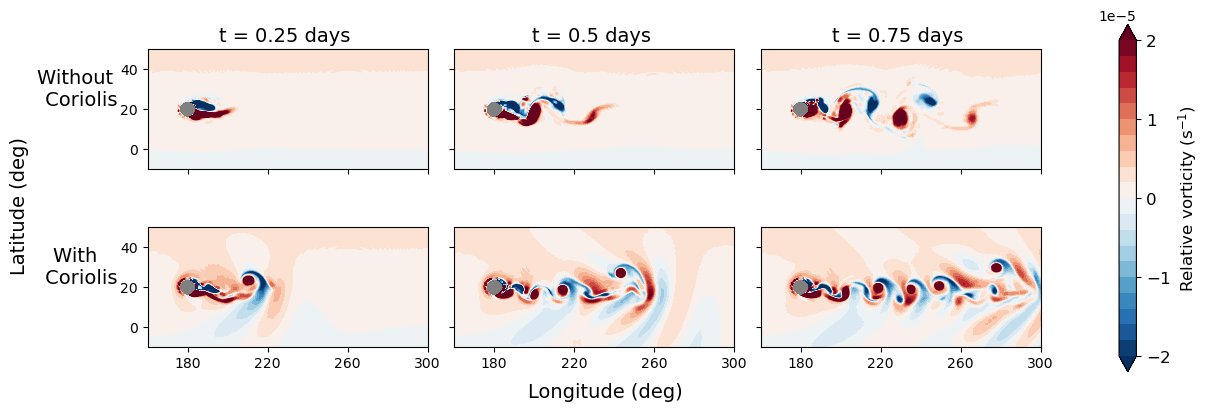

In [21]:
# relative vorticity over time, both omega0 and with rot
vort_cmap = copy.copy(matplotlib.cm.RdBu_r)
#vort_cmap.set_under('k')

fig, axes = plt.subplots(2,3, sharey=True, sharex=True, figsize = (12,4), layout="constrained")
(ax1, ax2, ax3), (ax4,ax5,ax6) = axes

absmax = 2e-5

vort_conts = np.linspace(-absmax, absmax, 21)
tick_range = np.linspace(-absmax, absmax, 5)
norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

plot1 = ax1.contourf(LON, LAT, vort1_omega0, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, vort2_omega0, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, vort3_omega0, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, vort1_rot, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot5 = ax5.contourf(LON, LAT, vort2_rot, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
plot6 = ax6.contourf(LON, LAT, vort3_rot, levels = vort_conts, cmap=vort_cmap, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

ax1.set_ylabel('Without \n Coriolis', rotation=0, labelpad=30, size=14)
ax4.set_ylabel('With \n Coriolis', rotation=0, labelpad=30, size=14)

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')
ax5.set_aspect('equal')
ax6.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")
ax5.set_facecolor("grey")
ax6.set_facecolor("grey")

cb = plt.colorbar(plot6, ax=axes, ticks = tick_range, fraction=0.2)
cb.set_label(label='Relative vorticity (s$^{-1}$)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f't = {time[t_idxs[0]]} days ', size=label_size)
ax2.set_title(f't = {time[t_idxs[1]]} days ', size=label_size)
ax3.set_title(f't = {time[t_idxs[2]]} days ', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
plt.savefig('figures/vortex_vort_over_time.png')